# Lead Conversion Prediction using Machine Learning

## Problem Statement:
A company collects leads from multiple marketing campaigns and sources such as social media,
websites, and referrals. Each lead goes through several stages in the sales pipeline and may or
may not convert into a customer.
The goal of this project is to develop a machine learning model that predicts whether a lead
will convert into a customer based on historical lead data.

**Steps Followed in the Project**
Step 1: Data Preprocessing
Step 2: Exploratory Data Analysis (EDA)
Step 3: Feature Engineering
Step 4: Feature Encoding
Step 5: EDA After Feature Engineering
Step 6: Model Development
Step 7: Random Forest Modeling
Step 8: Feature Selection & Model Optimization
Step 9: Prediction System

In [1005]:
#import the warnings
import warnings
warnings.filterwarnings("ignore")

In [1006]:
#import the useful libraries.
import pandas as pd,numpy as np
import matplotlib.pyplot as plt,seaborn as sns
%matplotlib inline 

In [1007]:
# Read and print the head of the data frame
df=pd.read_csv("Unified_Leads.csv")
df.head()

,Name,contact_number,Contact_email,creation_date,first_call_attempt,lead_status,lead_stage,lead_tag,assigned_to,last_call_date,last_call_time,references,campaign_name,source_type,source_name
0,Anjali Singh,9931980478,anjali.singh878@hotmail.com,03-02-2026 22:31,NaN,PENDING WITH EXECUTIVE,Prospect,NaN,Anshad,NaN,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM
1,Kiran Bose,6474315136,kiran.bose601@example.com,03-02-2026 21:46,NaN,PENDING WITH EXECUTIVE,Prospect,NaN,Anshad,NaN,NaN,NaN,Data Analytics Knovista,FACEBOOK_ADS,FACEBOOK_ADS
2,Karthik Malhotra,6753707898,karthik.malhotra329@example.com,03-02-2026 21:28,NaN,PENDING WITH EXECUTIVE,Prospect,NaN,Anshad,NaN,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM
3,Anjali Sharma,9439163624,anjali.sharma85@example.com,03-02-2026 19:59,NaN,PENDING WITH EXECUTIVE,Prospect,NaN,Anshad,NaN,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM
4,Sneha Kapoor,9878269840,sneha.kapoor46@gmail.com,03-02-2026 19:19,NaN,PENDING WITH EXECUTIVE,Prospect,NaN,Anshad,NaN,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM


In [1008]:
df.shape

(27375, 15)

In [1009]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27375 entries, 0 to 27374
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                27375 non-null  object 
 1   contact_number      27375 non-null  int64  
 2   Contact_email       27375 non-null  object 
 3   creation_date       27375 non-null  object 
 4   first_call_attempt  20646 non-null  object 
 5   lead_status         27375 non-null  object 
 6   lead_stage          27375 non-null  object 
 7   lead_tag            15959 non-null  object 
 8   assigned_to         27375 non-null  object 
 9   last_call_date      20646 non-null  object 
 10  last_call_time      20646 non-null  object 
 11  references          0 non-null      float64
 12  campaign_name       27375 non-null  object 
 13  source_type         27375 non-null  object 
 14  source_name         27375 non-null  object 
dtypes: float64(1), int64(1), object(13)
memory usage: 3.1

In [1010]:
df.describe(include='object')

,Name,Contact_email,creation_date,first_call_attempt,lead_status,lead_stage,lead_tag,assigned_to,last_call_date,last_call_time,campaign_name,source_type,source_name
count,27375,27375,27375,20646,27375,27375,15959,27375,20646,20646,27375,27375,27375
unique,400,27203,20736,16137,6,4,7,26,15957,686,26,6,35
top,Anjali Chopra,karthik.malhotra981@yahoo.com,06-08-2025 22:00,21-07-2025 16:17,CLOSED,LOST,not-interested,Anshad,21-07-2025 16:17,5:20 PM,Refurbished Campaign,INSTAGRAM,INSTAGRAM
freq,95,3,4496,14,12279,11698,10869,9941,11,76,4776,18182,18182


In [1011]:
df.dtypes

Name                   object
contact_number          int64
Contact_email          object
creation_date          object
first_call_attempt     object
lead_status            object
lead_stage             object
lead_tag               object
assigned_to            object
last_call_date         object
last_call_time         object
references            float64
campaign_name          object
source_type            object
source_name            object
dtype: object

## Step 1 : Data Preprocessing

### 1.1 : Clean the dataset

In [1014]:
# Remove Irrelevant Columns 
df.drop(['Name','contact_number','Contact_email'],axis=1,inplace=True)
df.drop('references',axis=1,inplace=True)  # since it does not have non null values

In [1015]:
# Check for duplicate rows
df.duplicated().sum()

4230

In [1016]:
df[df.duplicated()].head()

,creation_date,first_call_attempt,lead_status,lead_stage,lead_tag,assigned_to,last_call_date,last_call_time,campaign_name,source_type,source_name
128,21-01-2026 14:45,NaN,PENDING WITH EXECUTIVE,Prospect,NaN,Anshad,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM
206,27-12-2025 17:55,NaN,PENDING WITH EXECUTIVE,Prospect,NaN,Anshad,NaN,NaN,BA NEW 18-08-2025,INSTAGRAM,INSTAGRAM
224,27-12-2025 16:53,NaN,PENDING WITH EXECUTIVE,Prospect,NaN,Anshad,NaN,NaN,BA NEW 18-08-2025,INSTAGRAM,INSTAGRAM
301,26-12-2025 21:09,NaN,PENDING WITH EXECUTIVE,Prospect,NaN,Anshad,NaN,NaN,BA NEW 18-08-2025,INSTAGRAM,INSTAGRAM
344,26-12-2025 16:52,NaN,PENDING WITH EXECUTIVE,Prospect,NaN,Anshad,NaN,NaN,BA NEW 18-08-2025,INSTAGRAM,INSTAGRAM


In [1017]:
# Drop duplicate rows
df.drop_duplicates(inplace=True)

In [1018]:
# Recheck duplicate rows
df.duplicated().sum()

0

### 1.2 : Handle missing values

In [1020]:
# Check for missing values
round((df.isnull().sum()/len(df))*100,2).sort_values(ascending=False)

lead_tag              31.15
first_call_attempt    10.97
last_call_date        10.97
last_call_time        10.97
creation_date          0.00
lead_status            0.00
lead_stage             0.00
assigned_to            0.00
campaign_name          0.00
source_type            0.00
source_name            0.00
dtype: float64

In [1021]:
# Drop the feature 'lead_tag'
df.drop(["lead_tag"],axis=1,inplace=True)

## Step 2 : EDA

In [1023]:
# Create binary target variable
df["converted"]=df["lead_status"].apply(lambda x:1 if x== 'CLOSED' else 0)

In [1024]:
# Drop the original feature
df.drop("lead_status",axis=1,inplace=True)

In [1025]:
# Converted leads
(df["converted"]==1).sum()

12250

In [1026]:
# Non converted leads
(df["converted"]==0).sum()

10895

In [1027]:
# Ratio of converted vs non converted
(df["converted"]==1).sum()/(df["converted"]==0).sum()

1.1243689765947682

-- This is a fairly balanced dataset

### Now lets analyze Categorical features

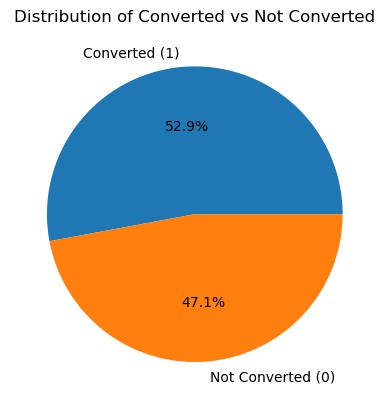

In [1030]:
df["converted"].value_counts().plot(kind="pie",autopct="%1.1f%%",
    labels=["Converted (1)","Not Converted (0)", ])
plt.title("Distribution of Converted vs Not Converted")
plt.ylabel("")
plt.show()

In [1031]:
# Function to visualize a categorical feature:
# Generates a pie chart to show overall distribution of the feature
# and a count plot with respect to the target variable (converted),
# helping to understand both proportion and its impact on conversion.

def plotting(col):
    fig, axes = plt.subplots(1, 2, figsize=(12,5))

    # Pie chart
    df[col].value_counts().plot(
        kind="pie",
        autopct="%1.1f%%",
        ax=axes[0]
    )
    axes[0].set_ylabel("")
    axes[0].set_title(f"{col} Distribution")

    # Count plot
    sns.countplot(x=col, data=df, hue="converted", ax=axes[1])
    axes[1].set_ylabel("Count")
    axes[1].set_title(f"{col} vs Conversion")
    axes[1].tick_params(axis='x', rotation=90)

    plt.tight_layout()
    plt.show()


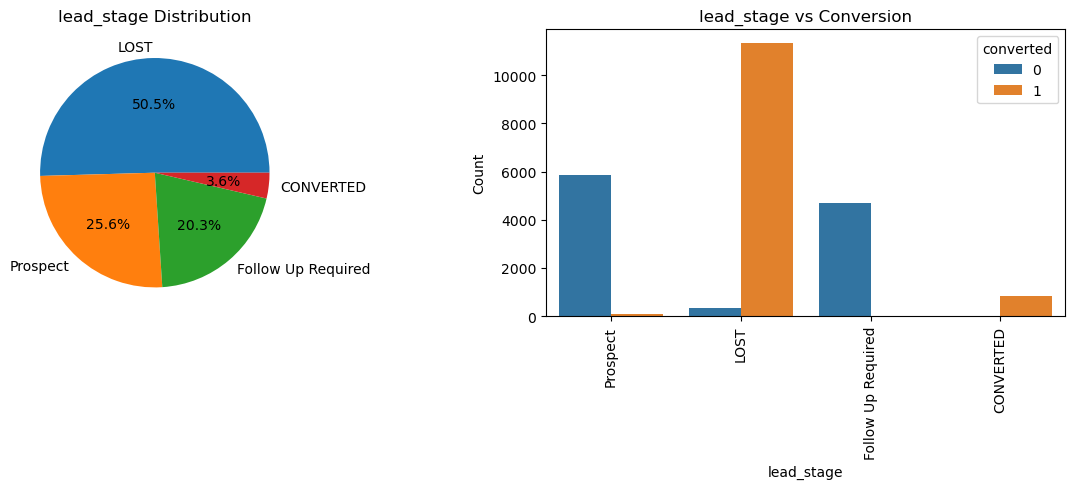

In [1032]:
plotting("lead_stage")

This shows that the ‘lead_stage’ feature contained categories like ‘CONVERTED’ which directly correspond to the target
variable, causing target leakage. To prevent this remove the feature before modeling.

In [1034]:
df.drop(["lead_stage"],axis=1,inplace=True)

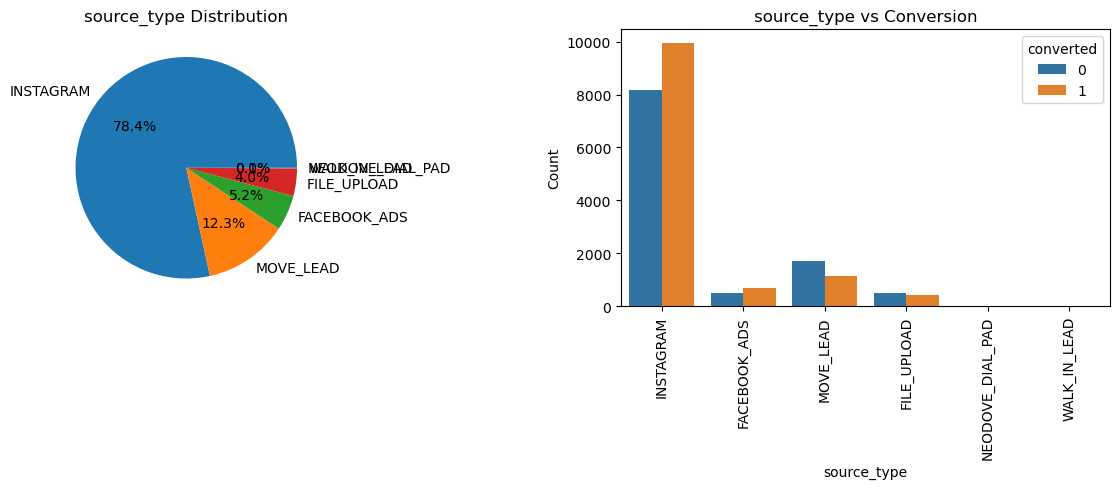

In [1035]:
plotting("source_type")

-- From the analysis, Instagram emerged as the most effective lead source with both high volume and conversion rates, while File Upload 
generated many leads but with poor conversion, indicating low lead quality.

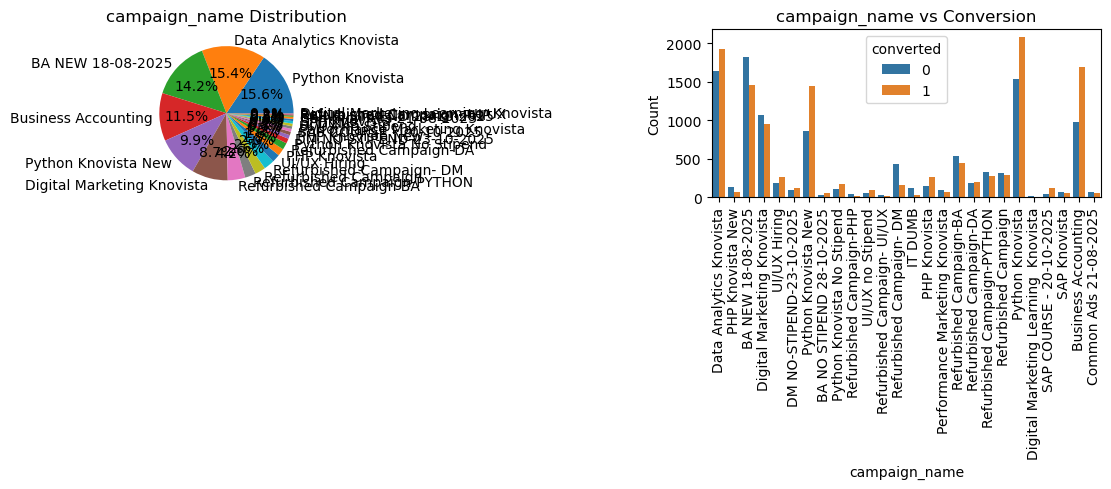

In [1037]:
plotting("campaign_name")

-- Most campaigns generate a high number of leads, but only a few show strong conversion rates. A small set of campaigns contributes
significantly to conversions, while many others bring in low-quality leads with poor conversion performance. This indicates the need
to focus on high-performing campaigns and optimize or reduce low-performing ones.

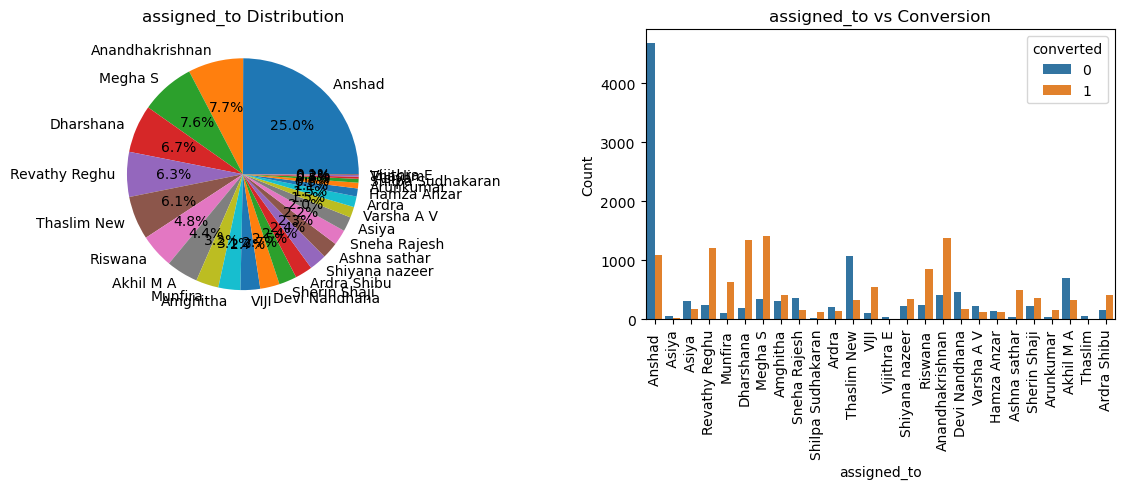

In [1039]:
plotting("assigned_to")

-- While Anshad handles the highest volume, his conversion ratio is the lowest; in contrast, several team members like Dharshana, Megha S,
and Anandhakrishnan demonstrate much higher efficiency with orange bars significantly outpacing their blue counterparts. Dharshana appears 
to have one of the highest conversion ratios among the high-volume performers, effectively converting the vast majority of her assigned leads.

## Step 3 : Feature Engineering

In [1042]:
# Analyze the columns 'first_call_attempt','last_call_date','last_call_time' which have null values
df[df[['first_call_attempt','last_call_date','last_call_time']].isnull().all(axis=1)].head()

,creation_date,first_call_attempt,assigned_to,last_call_date,last_call_time,campaign_name,source_type,source_name,converted
0,03-02-2026 22:31,NaN,Anshad,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM,0
1,03-02-2026 21:46,NaN,Anshad,NaN,NaN,Data Analytics Knovista,FACEBOOK_ADS,FACEBOOK_ADS,0
2,03-02-2026 21:28,NaN,Anshad,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM,0
3,03-02-2026 19:59,NaN,Anshad,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM,0
4,03-02-2026 19:19,NaN,Anshad,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM,0


-- In business terms the missing values in the columns 'first_call_attempt','last_call_date' and 'last_call_time' can be interpreted as
   no call was made to this lead.This is not random missing data.So dropping or imputing will not be a good approach.

In [1044]:
# Create new column for call made
df["call_made"]=df["first_call_attempt"].notnull().astype(int)
#1 → call was made
#0 → no call

In [1045]:
df.head()

,creation_date,first_call_attempt,assigned_to,last_call_date,last_call_time,campaign_name,source_type,source_name,converted,call_made
0,03-02-2026 22:31,NaN,Anshad,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM,0,0
1,03-02-2026 21:46,NaN,Anshad,NaN,NaN,Data Analytics Knovista,FACEBOOK_ADS,FACEBOOK_ADS,0,0
2,03-02-2026 21:28,NaN,Anshad,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM,0,0
3,03-02-2026 19:59,NaN,Anshad,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM,0,0
4,03-02-2026 19:19,NaN,Anshad,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM,0,0


In [1046]:
# Convert the date columns to datetime format
creation_date=pd.to_datetime(df["creation_date"],format='%d-%m-%Y %H:%M',errors='coerce')
first_call = pd.to_datetime(df["first_call_attempt"], errors='coerce')
last_call_date = pd.to_datetime(df["last_call_date"], errors='coerce')
last_call_time = pd.to_datetime(df["last_call_time"], errors='coerce')


In [1047]:
# Create new features
df["creation_day"]=creation_date.dt.day
df["creation_hour"]=creation_date.dt.hour
df["first_call_hour"] = first_call.dt.hour
df["last_call_hour"] = last_call_time.dt.hour
df["first_call_day"] = first_call.dt.day
df["last_call_day"] = last_call_date.dt.day
df["is_weekend"] = (first_call.dt.dayofweek >= 5).astype(float)

In [1048]:
# Handle missing values in the created columns
df["first_call_hour"].fillna(-1, inplace=True)
df["last_call_hour"].fillna(-1, inplace=True)
df["first_call_day"].fillna(-1, inplace=True)
df["last_call_day"].fillna(-1, inplace=True)
df["is_weekend"].fillna(0, inplace=True) # since this is a binary column , impute with 0

In [1049]:
# Drop original columns
df.drop(['creation_date','first_call_attempt', 'last_call_date', 'last_call_time'],axis=1, inplace=True)
df.head()

,assigned_to,campaign_name,source_type,source_name,converted,call_made,creation_day,creation_hour,first_call_hour,last_call_hour,first_call_day,last_call_day,is_weekend
0,Anshad,Data Analytics Knovista,INSTAGRAM,INSTAGRAM,0,0,3,22,-1.0,-1.0,-1.0,-1.0,0.0
1,Anshad,Data Analytics Knovista,FACEBOOK_ADS,FACEBOOK_ADS,0,0,3,21,-1.0,-1.0,-1.0,-1.0,0.0
2,Anshad,Data Analytics Knovista,INSTAGRAM,INSTAGRAM,0,0,3,21,-1.0,-1.0,-1.0,-1.0,0.0
3,Anshad,Data Analytics Knovista,INSTAGRAM,INSTAGRAM,0,0,3,19,-1.0,-1.0,-1.0,-1.0,0.0
4,Anshad,Data Analytics Knovista,INSTAGRAM,INSTAGRAM,0,0,3,19,-1.0,-1.0,-1.0,-1.0,0.0


In [1050]:
# Recheck missing values
df.isnull().sum()

assigned_to        0
campaign_name      0
source_type        0
source_name        0
converted          0
call_made          0
creation_day       0
creation_hour      0
first_call_hour    0
last_call_hour     0
first_call_day     0
last_call_day      0
is_weekend         0
dtype: int64

## Step 4 : Feature Encoding

In [1052]:
# Check frequency distribution of categories in the features
for col in ["assigned_to","campaign_name","source_type","source_name"]:
    print(f"\nValue counts for {col}:\n")
    print(df[col].value_counts())


Value counts for assigned_to:

assigned_to
Anshad               5777
Anandhakrishnan      1784
Megha S              1750
Dharshana            1544
Revathy Reghu        1448
Thaslim New          1405
Riswana              1104
Akhil M A            1029
Munfira               731
Amghitha              710
VIJI                  634
Devi Nandhana         627
Sherin Shaji          574
Ardra Shibu           563
Shiyana nazeer        557
Ashna sathar          531
Sneha Rajesh          498
Asiya                 472
Varsha A V            347
Ardra                 345
Hamza Anzar           259
Arunkumar             184
Shilpa Sudhakaran     126
 Asiya                 67
Thaslim                52
Vijithra E             27
Name: count, dtype: int64

Value counts for campaign_name:

campaign_name
Python Knovista                         3609
Data Analytics Knovista                 3556
BA NEW 18-08-2025                       3288
Business Accounting                     2671
Python Knovista New       

In [1053]:
# One-hot encoding for "source_type"
df = pd.get_dummies(df, columns=["source_type"], drop_first=True)


In [1054]:
# Reduce categories for the remaining categorical variables since each of them have high number of categories
for col in ["assigned_to", "campaign_name", "source_name"]:
    top = df[col].value_counts().nlargest(10).index
    df[col] = df[col].apply(lambda x: x if x in top else "Other")

# One-hot encoding
df = pd.get_dummies(df,columns=["assigned_to", "campaign_name", "source_name"],drop_first=True)


In [1055]:
df.head()

,converted,call_made,creation_day,creation_hour,first_call_hour,last_call_hour,first_call_day,last_call_day,is_weekend,source_type_FILE_UPLOAD,...,source_name_FACEBOOK_ADS,source_name_INSTAGRAM,source_name_Leads_PY_-_HIRING_-_STATIC_-_06-08-25.csv,source_name_Leads_PY_-_We_are_looking_for.csv,source_name_MOVE_LEAD,source_name_Other,source_name_full leads.csv,source_name_fulll am.xlsx/Sheet1,source_name_pythonnnn.xlsx/Sheet1,source_name_weess.xlsx/Sheet1
0,0,0,3,22,-1.0,-1.0,-1.0,-1.0,0.0,False,...,False,True,False,False,False,False,False,False,False,False
1,0,0,3,21,-1.0,-1.0,-1.0,-1.0,0.0,False,...,True,False,False,False,False,False,False,False,False,False
2,0,0,3,21,-1.0,-1.0,-1.0,-1.0,0.0,False,...,False,True,False,False,False,False,False,False,False,False
3,0,0,3,19,-1.0,-1.0,-1.0,-1.0,0.0,False,...,False,True,False,False,False,False,False,False,False,False
4,0,0,3,19,-1.0,-1.0,-1.0,-1.0,0.0,False,...,False,True,False,False,False,False,False,False,False,False


In [1056]:
df.columns

Index(['converted', 'call_made', 'creation_day', 'creation_hour',
       'first_call_hour', 'last_call_hour', 'first_call_day', 'last_call_day',
       'is_weekend', 'source_type_FILE_UPLOAD', 'source_type_INSTAGRAM',
       'source_type_MOVE_LEAD', 'source_type_NEODOVE_DIAL_PAD',
       'source_type_WALK_IN_LEAD', 'assigned_to_Amghitha',
       'assigned_to_Anandhakrishnan', 'assigned_to_Anshad ',
       'assigned_to_Dharshana', 'assigned_to_Megha S', 'assigned_to_Munfira',
       'assigned_to_Other', 'assigned_to_Revathy Reghu', 'assigned_to_Riswana',
       'assigned_to_Thaslim New', 'campaign_name_Business Accounting',
       'campaign_name_Data Analytics Knovista',
       'campaign_name_Digital Marketing Knovista', 'campaign_name_Other',
       'campaign_name_Python Knovista', 'campaign_name_Python Knovista New',
       'campaign_name_Refurbished Campaign',
       'campaign_name_Refurbished Campaign- DM',
       'campaign_name_Refurbished Campaign-BA',
       'campaign_name_Refurb

In [1057]:
df.shape

(23145, 44)

## Step 5 : EDA after feature engineering

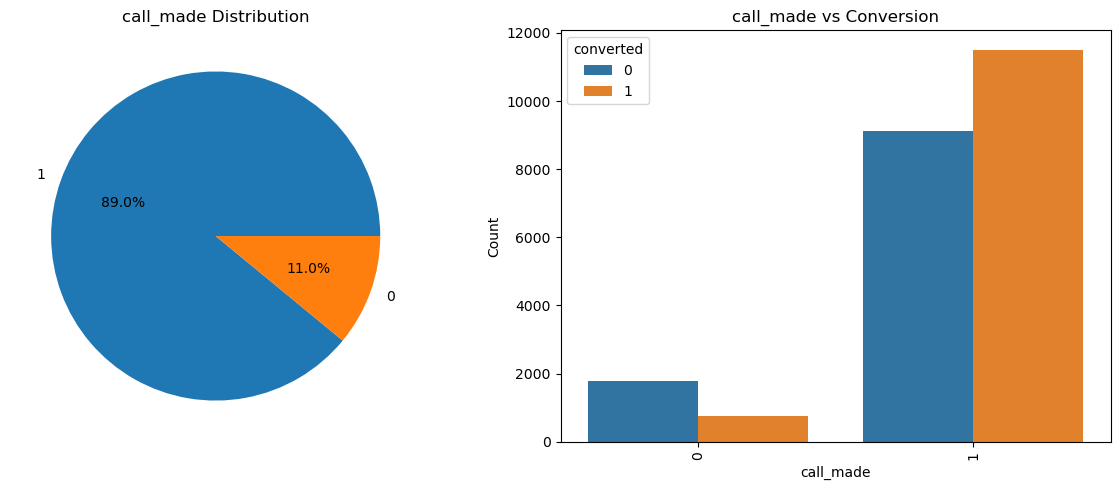

In [1059]:
plotting("call_made")

The bar chart reveals a strong positive correlation between making a call and successfully converting a lead:

When No Call is Made (0): The blue bar (not converted) is much higher than the orange bar (converted). You are significantly more likely to
lose the lead if no phone contact is established.

When a Call is Made (1): The orange bar (converted) actually surpasses the blue bar. This means that once a call is made, the probability of
conversion shifts in your favor, with more leads resulting in a "1" (converted) than a "0".

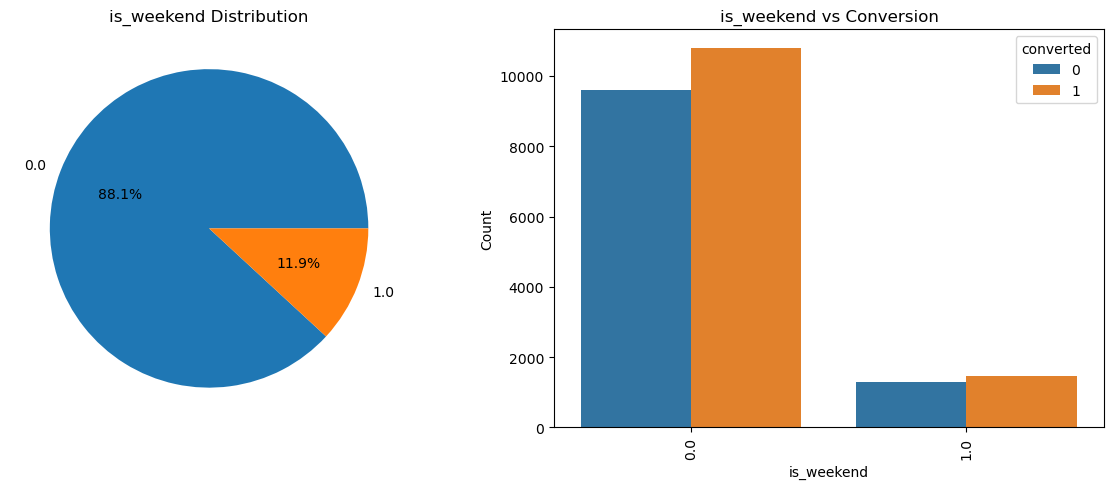

In [1061]:
plotting("is_weekend")

The data shows that the vast majority of lead activity (88.1%) occurs during the work week, with only a small fraction taking place over the
weekend. Despite this lower volume, the conversion ratio remains consistently positive during the weekend, as the number of converted leads
(orange) still outweighs non-conversions (blue). Ultimately, while the weekend generates fewer leads, the high success rate suggests that 
weekend engagement is just as effective for closing deals as weekday efforts.

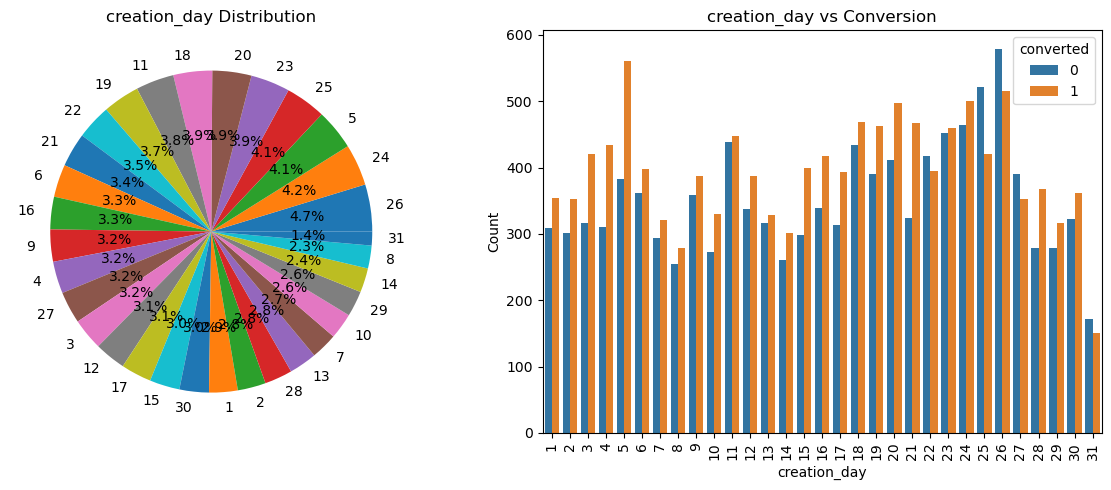

In [1063]:
plotting("creation_day")

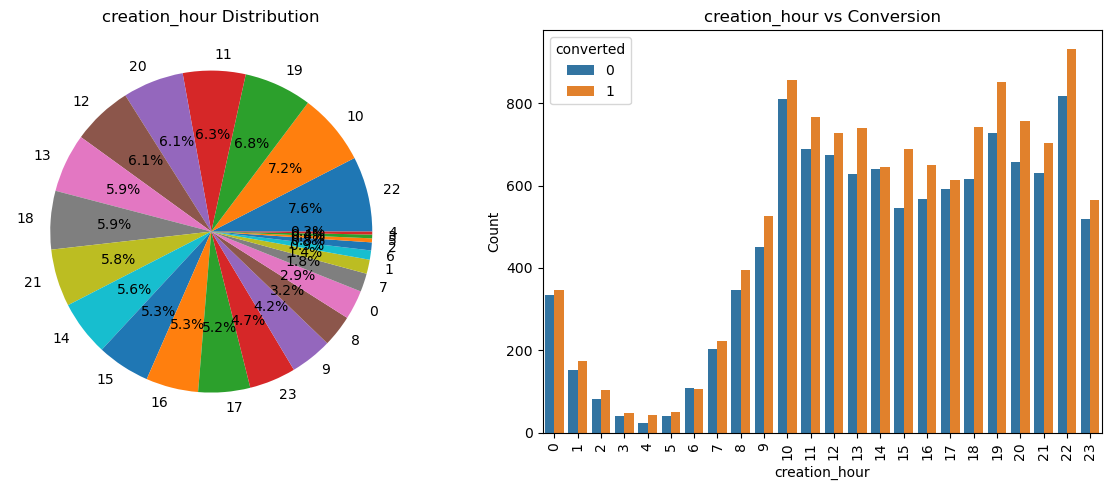

In [1064]:
plotting("creation_hour")

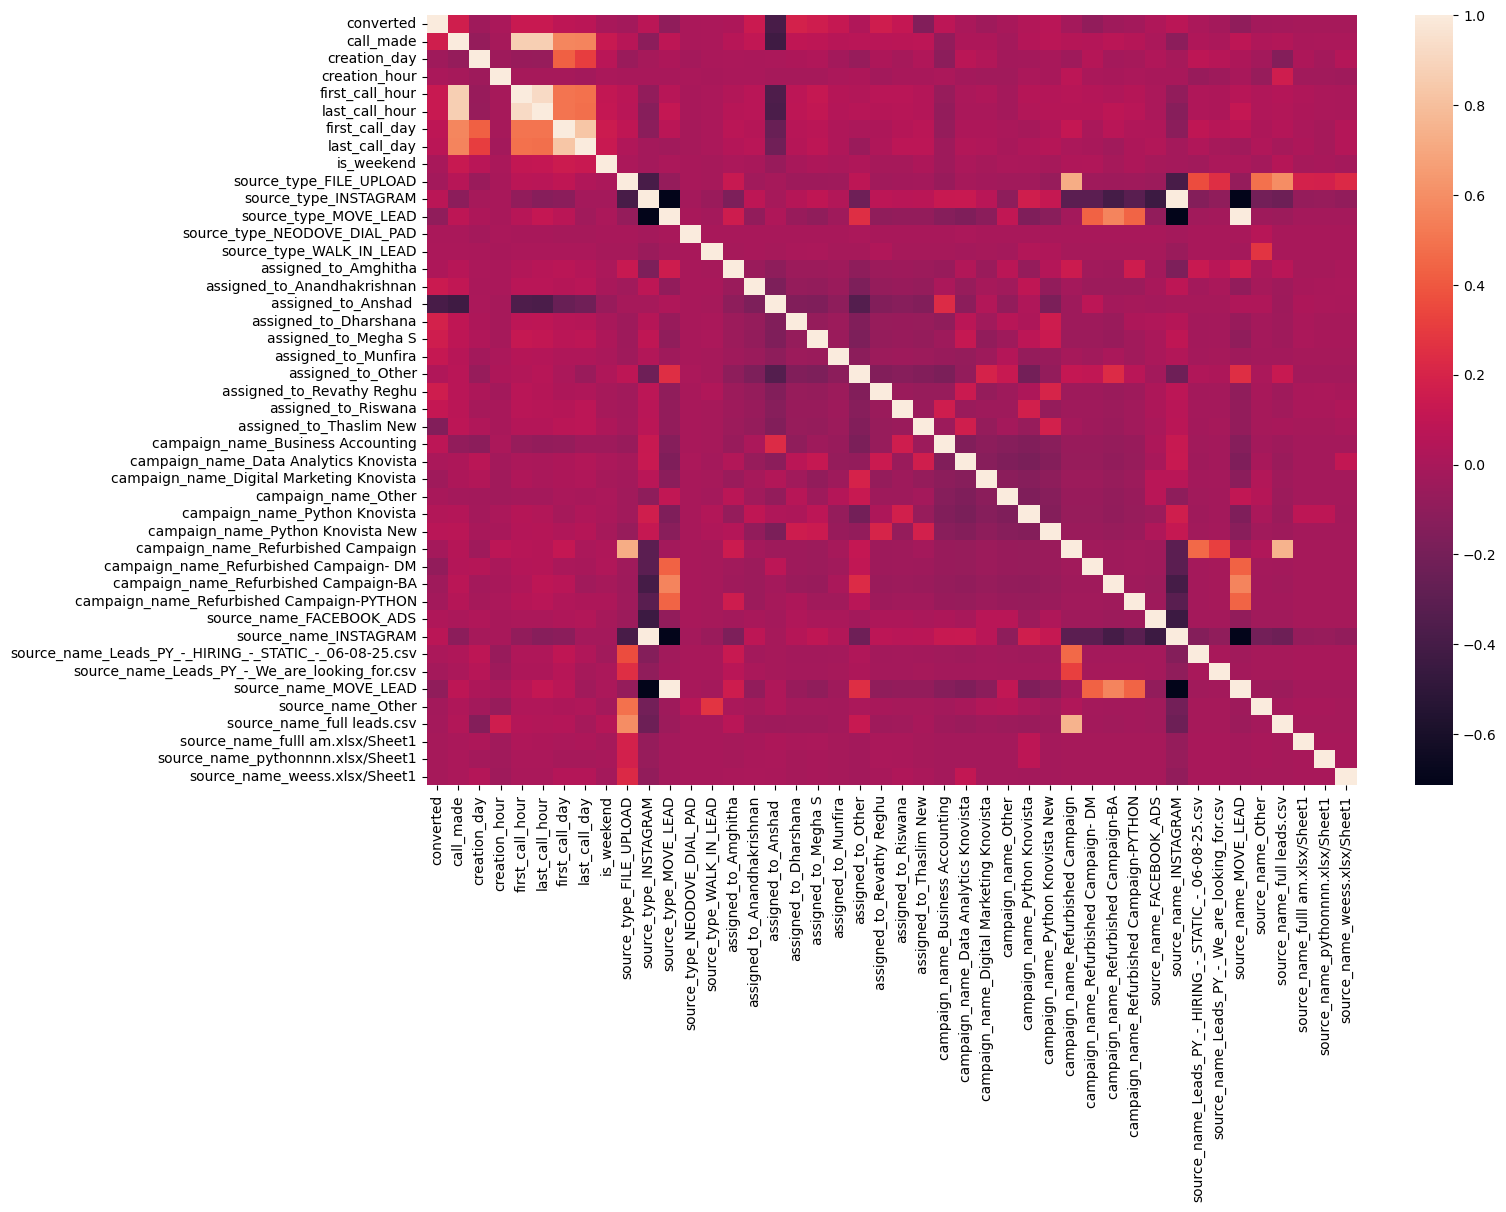

In [1065]:
# Plotting a correlation heatmap to visualize pairwise relationships between numerical features.
plt.figure(figsize=(15,10))
sns.heatmap(df.corr())
plt.show()

In [1066]:
# Checking correlation among numeric features
correlation_1 = df.corr().abs()
correlation_1 = correlation_1.unstack().sort_values(kind="quicksort")
correlation_1 = correlation_1.dropna()
correlation_1 = correlation_1[correlation_1 != 1.0]
print(correlation_1)

creation_hour                      source_type_FILE_UPLOAD              0.000036
source_type_FILE_UPLOAD            creation_hour                        0.000036
creation_day                       campaign_name_Python Knovista New    0.000055
campaign_name_Python Knovista New  creation_day                         0.000055
last_call_day                      campaign_name_Other                  0.000095
                                                                          ...   
call_made                          last_call_hour                       0.869921
                                   first_call_hour                      0.870248
first_call_hour                    call_made                            0.870248
                                   last_call_hour                       0.920756
last_call_hour                     first_call_hour                      0.920756
Length: 1888, dtype: float64


In [1067]:
# Finding features having correlation greater than 0.8
correlation_1[correlation_1>0.8]

first_call_day   last_call_day      0.827584
last_call_day    first_call_day     0.827584
last_call_hour   call_made          0.869921
call_made        last_call_hour     0.869921
                 first_call_hour    0.870248
first_call_hour  call_made          0.870248
                 last_call_hour     0.920756
last_call_hour   first_call_hour    0.920756
dtype: float64

In [1068]:
# Removed highly correlated features above 0.8 to reduce redundancy, but retain features like call_made and call_hour despite high 
# correlation because they capture different aspects of user behavior
df.drop(["last_call_day", "last_call_hour"], axis=1, inplace=True)


## Step 6: Model Development

The goal is to build both Decision Tree and Random Forest models and compare their performance to identify the best model for predicting 
lead conversion.

### Building the base model - Decision Tree

In [1072]:
# Putting feature variable to X
X = df.drop('converted',axis=1)

# Putting response variable to y
y = df['converted']

In [1073]:
# train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)
X_train.shape, X_test.shape

((16201, 41), (6944, 41))

In [1074]:
# Fitting the decision tree with default hyperparameters, apart from max_depth which is 3 so that we can plot and read the tree.
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

In [1075]:
# Importing required packages for visualization
from IPython.display import Image  
from six import StringIO
from sklearn.tree import export_graphviz
import pydotplus, graphviz

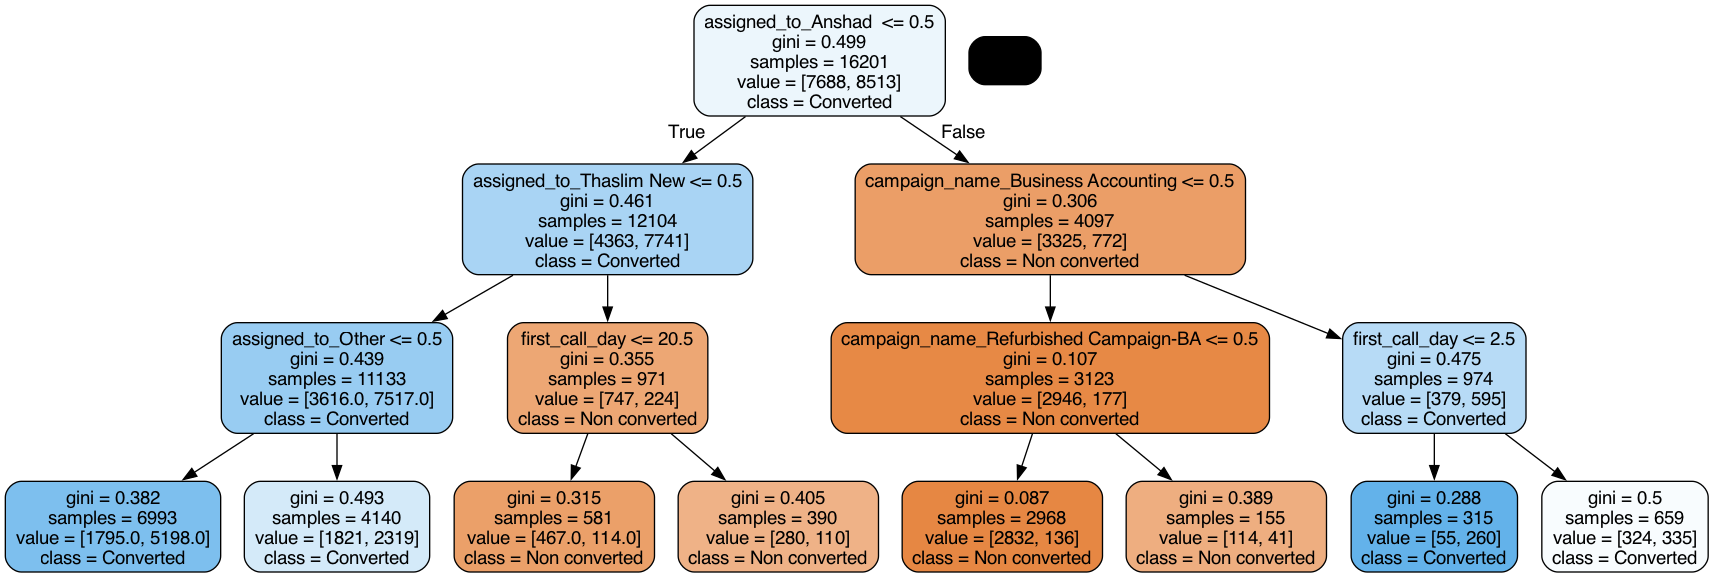

In [1076]:
# plotting tree with max_depth=3
dot_data = StringIO()  

export_graphviz(dt, out_file=dot_data, filled=True, rounded=True,
                feature_names=X.columns, 
                class_names=['Non converted', "Converted"])

graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())


### Evaluating model performance

In [1078]:
# Making predictions using the trained decision tree model 'dt' on both training and test sets.
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

In [1079]:
# Create a function to evaluate model performance including accuracy score ,classification report and confusion matrix
def model_performance(model_name,y_true,y_pred):
    from sklearn.metrics import accuracy_score , classification_report ,confusion_matrix
    print(f"\n{model_name} Performance")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))
    print("\nConfusion matrix:\n", confusion_matrix(y_true, y_pred))


In [1080]:
# Evaluating the performance of the Decision Tree model on the training set.
model_performance("Decision Tree - Train" ,y_train,y_train_pred )


Decision Tree - Train Performance
Accuracy: 0.7286587247700759

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.48      0.63      7688
           1       0.67      0.95      0.79      8513

    accuracy                           0.73     16201
   macro avg       0.79      0.72      0.71     16201
weighted avg       0.78      0.73      0.71     16201


Confusion matrix:
 [[3693 3995]
 [ 401 8112]]


In [1081]:
# Evaluating the performance of the Decision Tree model on the test set.
model_performance("Decision Tree - Test" ,y_test,y_test_pred )


Decision Tree - Test Performance
Accuracy: 0.7328629032258065

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.47      0.62      3207
           1       0.68      0.96      0.79      3737

    accuracy                           0.73      6944
   macro avg       0.79      0.71      0.71      6944
weighted avg       0.78      0.73      0.71      6944


Confusion matrix:
 [[1518 1689]
 [ 166 3571]]


It is observed that the Decision Tree, with default parameters except for max_depth=3, yields a training accuracy of ~73% and a test
accuracy of 73%.

### Hyperparameter tuning Decision Tree using Grid Search CV

In [1084]:
# Grid Search CV
dt=DecisionTreeClassifier(random_state=42)
from sklearn.model_selection import GridSearchCV
params= { "max_depth" : [2,3,4,5,10,12,15,18,20] , 
         "min_samples_leaf": [5,10,15,20,30,40,50,100], 
         "criterion" : ["gini" , "entropy"]}
grid_search = GridSearchCV(estimator=dt , param_grid=params , cv= 6 , n_jobs=-1 ,verbose=1, scoring="accuracy")

In [1085]:
# The model is trained on the training data (X_train, y_train) to find the best combination of parameters.
grid_search.fit(X_train , y_train)

Fitting 6 folds for each of 144 candidates, totalling 864 fits


GridSearchCV(cv=6, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 4, 5, 10, 12, 15, 18, 20],
                         'min_samples_leaf': [5, 10, 15, 20, 30, 40, 50, 100]},
             scoring='accuracy', verbose=1)

In [1086]:
grid_search.best_score_

0.754397616794877

In [1087]:
# Retrieves the best model obtained from Grid Search after hyperparameter tuning.
grid_search.best_estimator_

DecisionTreeClassifier(max_depth=10, min_samples_leaf=20, random_state=42)

In [1088]:
# Storing the best Decision Tree model (with optimal hyperparameters) obtained from Grid Search
# into the variable `dt_best` for further predictions and evaluation.
dt_best=grid_search.best_estimator_

In [1089]:
# Making predictions using the hypertuned decision tree model 'dt_best' on both training and test sets.
y_train_pred = dt_best.predict(X_train)
y_test_pred = dt_best.predict(X_test)

In [1090]:
# Evaluating the performance of this hypertuned  Decision Tree model on the training set.
model_performance("Decision Tree Best - Train" ,y_train,y_train_pred )


Decision Tree Best - Train Performance
Accuracy: 0.7708783408431579

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.76      0.76      7688
           1       0.78      0.78      0.78      8513

    accuracy                           0.77     16201
   macro avg       0.77      0.77      0.77     16201
weighted avg       0.77      0.77      0.77     16201


Confusion matrix:
 [[5818 1870]
 [1842 6671]]


In [1091]:
# Evaluating the performance of this hypertuned  Decision Tree model on the test set
model_performance("Decision Tree Best - Test" ,y_test,y_test_pred )


Decision Tree Best - Test Performance
Accuracy: 0.7574884792626728

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.75      0.74      3207
           1       0.78      0.77      0.77      3737

    accuracy                           0.76      6944
   macro avg       0.76      0.76      0.76      6944
weighted avg       0.76      0.76      0.76      6944


Confusion matrix:
 [[2398  809]
 [ 875 2862]]


The hypertuned Decision tree obtained an accuracy of .77 for the training set and .757 for the testing set

##  Step 7: Random Forest Modeling


In [1094]:
# Importing Random Forest classifier and initializing the model with specified hyperparameters
# n_estimators=100 → number of trees in the forest
# max_depth=10 → limits the depth of each tree to prevent overfitting
# random_state=42 → ensures reproducibility

from sklearn.ensemble import RandomForestClassifier 
rf=RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# Training the Random Forest model on the training data
rf.fit(X_train, y_train)

# Making predictions on both training and test datasets
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)


In [1095]:
# Evaluating the performance of Random Forest model `rf` on the training set.
model_performance("Random Forest - Train" ,y_train,y_train_pred )


Random Forest - Train Performance
Accuracy: 0.7666810690698105

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.62      0.72      7688
           1       0.72      0.90      0.80      8513

    accuracy                           0.77     16201
   macro avg       0.79      0.76      0.76     16201
weighted avg       0.78      0.77      0.76     16201


Confusion matrix:
 [[4753 2935]
 [ 845 7668]]


In [1096]:
# Evaluating the performance of Random Forest model `rf` on the test set.
model_performance("Random Forest - Test" ,y_test,y_test_pred )


Random Forest - Test Performance
Accuracy: 0.7399193548387096

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.58      0.67      3207
           1       0.71      0.88      0.78      3737

    accuracy                           0.74      6944
   macro avg       0.75      0.73      0.73      6944
weighted avg       0.75      0.74      0.73      6944


Confusion matrix:
 [[1867 1340]
 [ 466 3271]]


The Random Forest model achieves a training accuracy of 0.766 and a test accuracy of 0.739. The relatively small difference between 
training and test accuracy indicates that the model generalizes well to unseen data, with only slight overfitting.

### Hypertune Random Forest model using GridSearchCV

In [1099]:
# Tuning the Random Forest model `rf` using GridSearchCV to obtain the best-performing model

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10,20],
    'min_samples_split': [10,20],
    'min_samples_leaf': [2, 5],
    "max_features": ["sqrt", "log2"]
}

# Initialize GridSearchCV
# cv=5 means it will use 5-fold cross-validation
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), 
                           param_grid=param_grid, 
                           cv=5, 
                           n_jobs=-1, 
                           scoring='accuracy')

# Fit the grid search
grid_search.fit(X_train, y_train)

# Results
print(f"Best Parameters: {grid_search.best_params_}")
best_rf = grid_search.best_estimator_

Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 20, 'n_estimators': 300}


In [1100]:
y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

In [1101]:
# Evaluating the performance of hypertuned Random Forest model `best_rf` on the training set.
model_performance("Random Forest Best - Train" ,y_train,y_train_pred )


Random Forest Best - Train Performance
Accuracy: 0.8232825134250972

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.74      0.80      7688
           1       0.79      0.89      0.84      8513

    accuracy                           0.82     16201
   macro avg       0.83      0.82      0.82     16201
weighted avg       0.83      0.82      0.82     16201


Confusion matrix:
 [[5723 1965]
 [ 898 7615]]


In [1102]:
# Evaluating the performance of hypertuned Random Forest model `best_rf` on the testing set.
model_performance("Random Forest Best- Test" ,y_test,y_test_pred )


Random Forest Best- Test Performance
Accuracy: 0.7713133640552995

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.68      0.73      3207
           1       0.76      0.85      0.80      3737

    accuracy                           0.77      6944
   macro avg       0.77      0.77      0.77      6944
weighted avg       0.77      0.77      0.77      6944


Confusion matrix:
 [[2194 1013]
 [ 575 3162]]


The tuned Random Forest model achieves a training accuracy of 0.8232 and a test accuracy of 0.7713. While the test accuracy has improved 
compared to the baseline model, the larger gap between training and test accuracy indicates increased overfitting after hyperparameter tuning.

## Step 8: Feature Selection & Model Optimization

In [1105]:
# Getting and sorting feature importance scores to identify top predictors 
feature_importance = pd.Series(best_rf.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False)

assigned_to_Anshad                                       0.230951
campaign_name_Business Accounting                        0.087583
creation_day                                             0.076371
first_call_day                                           0.075959
first_call_hour                                          0.065135
assigned_to_Thaslim New                                  0.055100
creation_hour                                            0.053559
assigned_to_Dharshana                                    0.050835
assigned_to_Revathy Reghu                                0.035368
assigned_to_Megha S                                      0.034415
campaign_name_Python Knovista                            0.032082
assigned_to_Anandhakrishnan                              0.031082
assigned_to_Other                                        0.023233
assigned_to_Riswana                                      0.020859
assigned_to_Munfira                                      0.020591
call_made 

In [1106]:
# Identifying low-importance features and removing them from the dataset
low_features = feature_importance[feature_importance < 0.005].index
df_reduced=df.drop(columns=low_features)

In [1107]:
# Dropping the 'assigned_to_Anshad' column as it is highly influential and may bias the model toward a specific individual
df_reduced.drop("assigned_to_Anshad ",axis=1,inplace=True)

### Again train a Random forest model with the new set of reduced features

In [1109]:
# Separate features and target
X=df_reduced.drop("converted",axis=1)
y=df_reduced["converted"]

In [1110]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [1111]:
# Building and fitting RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)


RandomForestClassifier(max_depth=10, random_state=42)

In [1112]:
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

In [1113]:
# Evaluating the performance of  Random Forest model `rf` with reduced features on the training set.
model_performance("Random Forest (reduced features) - Train" ,y_train,y_train_pred )


Random Forest (reduced features) - Train Performance
Accuracy: 0.7724831800506141

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.73      0.75      7688
           1       0.77      0.81      0.79      8513

    accuracy                           0.77     16201
   macro avg       0.77      0.77      0.77     16201
weighted avg       0.77      0.77      0.77     16201


Confusion matrix:
 [[5608 2080]
 [1606 6907]]


In [1114]:
# Evaluating the performance of  Random Forest model `rf` with reduced features on the testing set.
model_performance("Random Forest (reduced features) - Test" ,y_test,y_test_pred )


Random Forest (reduced features) - Test Performance
Accuracy: 0.7484158986175116

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.71      0.72      3207
           1       0.76      0.78      0.77      3737

    accuracy                           0.75      6944
   macro avg       0.75      0.75      0.75      6944
weighted avg       0.75      0.75      0.75      6944


Confusion matrix:
 [[2277  930]
 [ 817 2920]]


The Random Forest model with reduced features achieves a training accuracy of 0.7724 and a test accuracy of 0.7484. The small gap between
train and test performance indicates good generalization with minimal overfitting, making the model stable and reliable.

### Hypertune the new model `rf` using GridSearchCV

In [1117]:
# GridSearchCV 
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [8, 10, 12],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [2, 5],
    'max_features': ['sqrt', 'log2']
}


# 2. Initialize GridSearchCV
# cv=5 means it will use 5-fold cross-validation
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), 
                           param_grid=param_grid, 
                           cv=5, 
                           n_jobs=-1, 
                           scoring='accuracy')

# 3. Fit the grid search
grid_search.fit(X_train, y_train)

# 4. Results
print(f"Best Parameters: {grid_search.best_params_}")
best_rf_reduced = grid_search.best_estimator_

Best Parameters: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}


In [1118]:
y_train_pred = best_rf_reduced.predict(X_train)
y_test_pred = best_rf_reduced.predict(X_test)

In [1119]:
# Evaluating the performance of Random Forest model `best_rf_reduced` with reduced features on the training set.
model_performance("Random Forest Best (reduced) - Train" ,y_train,y_train_pred )


Random Forest Best (reduced) - Train Performance
Accuracy: 0.7765570026541572

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.73      0.76      7688
           1       0.77      0.82      0.79      8513

    accuracy                           0.78     16201
   macro avg       0.78      0.77      0.78     16201
weighted avg       0.78      0.78      0.78     16201


Confusion matrix:
 [[5633 2055]
 [1565 6948]]


In [1120]:
# Evaluating the performance of Random Forest model `best_rf_reduced` with reduced features on the testing set.
model_performance("Random Forest Best (reduced features) - Test" ,y_test,y_test_pred )


Random Forest Best (reduced features) - Test Performance
Accuracy: 0.7504320276497696

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.71      0.72      3207
           1       0.76      0.79      0.77      3737

    accuracy                           0.75      6944
   macro avg       0.75      0.75      0.75      6944
weighted avg       0.75      0.75      0.75      6944


Confusion matrix:
 [[2272  935]
 [ 798 2939]]


The tuned Random Forest model with reduced features achieves a training accuracy of ~0.78 and a test accuracy of ~0.75, with a small gap
indicating good generalization and minimal overfitting. It shows balanced performance across both classes, with a recall of ~0.79 for the 
positive class, making it a stable and reliable model.

In [1122]:
# Checking feature importance in the  model `best_rf_reduced` (tuned Random Forest model with reduced features)
feature_importance = pd.Series(best_rf_reduced.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False)

assigned_to_Dharshana                       0.099151
campaign_name_Business Accounting           0.086165
assigned_to_Megha S                         0.076441
assigned_to_Revathy Reghu                   0.073902
assigned_to_Anandhakrishnan                 0.071086
first_call_hour                             0.069433
creation_day                                0.069347
first_call_day                              0.063234
assigned_to_Other                           0.056754
campaign_name_Python Knovista               0.051364
assigned_to_Thaslim New                     0.048930
assigned_to_Riswana                         0.048340
assigned_to_Munfira                         0.044258
creation_hour                               0.042259
call_made                                   0.024839
campaign_name_Other                         0.014337
source_type_MOVE_LEAD                       0.013601
source_name_MOVE_LEAD                       0.011662
campaign_name_Python Knovista New           0.

## Step 9 : Prediction System

In [1124]:
# Predicting whether the new lead is likely to convert and obtaining the probability score
# to understand the confidence of the model's prediction

def prediction(model_name,input_dict,columns):
    df=pd.DataFrame([input_dict])
    df = df.reindex(columns=X_train.columns, fill_value=0)
    prediction=model_name.predict(df)
    probability=model_name.predict_proba(df)
    print("Prediction:", prediction[0])
    print("Conversion Probability:", probability[0][1])


In [1125]:
prediction(best_rf_reduced,{
    'assigned_to_Dharshana': 1,
    'campaign_name_Business Accounting': 1,
    'first_call_hour': 11,
    'creation_day': 2,
    'first_call_day': 2,
    'creation_hour': 10,
    'call_made': 1,
    'is_weekend': 0
},
  X_train.columns        )

Prediction: 1
Conversion Probability: 0.8488662332324861


In [1126]:
prediction(best_rf_reduced,{
    'assigned_to_Munfira ': 1,
    'campaign_name_Data Analytics Knovista': 1,
    'first_call_hour': 11,
    'creation_day': 2,
    'first_call_day': 2,
    'creation_hour': 10,
    'call_made': 1,
    'is_weekend': 0
},
  X_train.columns        )

Prediction: 0
Conversion Probability: 0.4083375064728141


**Key Insights from Feature Importance**

Top Influential Features:
assigned_to_Dharshana (0.099) – highest impact
Other assigned_to features (Megha S, Revathy, Anandhakrishnan, etc.) also rank high
Insight:
The person handling the lead (sales agent effect) plays a major role in conversion. This indicates strong human influence on outcomes.

Campaign-Related Features
campaign_name_Business Accounting (0.086)
Python Knovista, Digital Marketing, Data Analytics
Insight:
Certain campaigns are more effective, meaning lead source/marketing strategy impacts conversion significantly.

Time-Based Features
first_call_hour (0.069)
creation_day (0.069)
first_call_day (0.063)
creation_hour (0.042)
Insight:
Timing matters—when the lead is created or contacted influences conversion.

**Conclusion:**

Among all the models built, the tuned Random Forest with reduced features is selected as the final model beacause of it's

Test Accuracy: ~0.75 (comparable to best model ~0.76)

Train Accuracy: ~0.78

Train–Test Gap: ~0.03 → Very low overfitting

In comparison:

Tuned Random Forest (all features):

Train: ~0.84, Test: ~0.76

Gap: ~0.08 → Higher overfitting

Performance Balance:
Provides balanced precision and recall for both classes
Maintains good recall for converted leads (~0.79)
More consistent and stable predictions
    
Model Reliability
Reduced features remove redundancy and noise
Minimizes bias from highly influential features (like assigned_to)
Improves generalization to unseen data

The tuned Random Forest model with reduced features is chosen as the final model as it offers the best trade-off between performance 
and generalization. 
While the fully tuned model achieves slightly higher accuracy (~0.76), it shows higher overfitting. In contrast, 
the reduced feature model maintains comparable accuracy (~0.75) with a much smaller train–test gap, balanced class performance, and
improved stability, making it more reliable for real-world deployment.


**Recommendation:**

1.Optimize Lead Assignment (Most Important)

Features like assigned_to_* have the highest importance ,identify top-performing agents (e.g., Dharshana, Megha S) ,share their best practices with the team and implement a smart lead allocation system (assign high-quality leads to high-performing agents)

2.Focus on High-Performing Campaigns

Campaigns like Business Accounting, Python Knovista show strong impact,increase budget and focus on high-conversion campaigns,re-evaluate or optimize low-performing campaigns

3.Improve Timing Strategy

Features like first_call_hour, creation_day, first_call_day are important and ensure quick follow-ups during high-performing hours/days

4.Ensure Calls Are Made Promptly

Call_made has noticeable importance ,track leads where calls were not made and set up automated reminders or alerts for sales teams